# Robust XGBoost Pipeline for Heat-Exchanger Fouling Detection
### Diagnosing and Eliminating Overfitting in a Synthetic Fouling Dataset

This notebook performs a full diagnostic audit of `fouling_dataset_paper_formulas_v2.csv`,
identifies the root causes of the severe overfitting observed in earlier modeling attempts,
and builds a leakage-free, properly regularized, cross-validated XGBoost pipeline for both
**classification** (fouling severity: NORMAL / LOW / MODERATE / HIGH) and **regression**
(continuous fouling resistance, `R_overall`).

**Headline finding:** the overfitting was not primarily an XGBoost hyperparameter problem.
It was a **data leakage problem**: several columns in the dataset are deterministic or
near-deterministic functions of the variables used to define the fouling label. Once those
columns are removed and replaced with a small set of physically-grounded, sensor-derivable
engineered features, a properly tuned, regularized model generalizes well (small, stable
train/CV/test gaps) without needing aggressive depth restriction as a band-aid.


## 1. Setup

Standard imports for data handling, modeling, and visualization.


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import spearmanr, pearsonr

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)

import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "figure.facecolor": "white", "savefig.bbox": "tight",
})
PALETTE = sns.color_palette("viridis", n_colors=4)

DATA_PATH = "fouling_dataset_paper_formulas_v2.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Loaded 15625 rows, 27 columns


,M_flue,M_w,T_fi,T_wi,f1,f2,M_flue_f,M_w_f,T_fo,T_wo,...,Cmax,Cr,dp_water_clean,dp_water_fouled,R1,R2,R_overall,Q_heat_exchanged,energy_balance_error,fouling_class
0,7.482802,5.094897,238.687834,26.973680,0.000165,0.000517,7.101121,5.094897,211.176860,37.064208,...,21296.667594,0.366782,128092.666914,232152.802325,0.000165,0.000517,0.000682,214894.614237,0.000000e+00,LOW
1,7.425129,8.532037,180.249091,24.503859,0.000649,0.000491,5.875774,8.532037,163.502045,27.538917,...,35663.913081,0.181229,328537.012302,577964.681950,0.000649,0.000491,0.001140,108242.042014,1.455192e-11,MODERATE
2,6.897393,8.895340,205.473136,22.272387,0.000971,0.000034,4.689210,8.895340,178.688823,25.988031,...,37182.521080,0.138725,361028.489623,375347.960886,0.000971,0.000034,0.001004,138156.997678,5.820766e-11,MODERATE
3,7.724340,7.003478,230.647019,23.545260,0.001699,0.000473,3.132963,7.003478,206.814646,26.350856,...,29274.536164,0.117722,229209.517132,395042.688292,0.001699,0.000473,0.002172,82132.525814,2.910383e-11,HIGH
4,7.502726,2.676923,207.337680,20.438038,0.000270,0.000362,6.870535,2.676923,181.523438,37.873377,...,11189.539008,0.675416,40091.378955,60793.304499,0.000270,0.000362,0.000632,195093.414761,8.731149e-11,LOW


## 2. Dataset Audit

We check, in order: missingness, duplicate rows, class balance, and — most importantly —
**data leakage**: columns that are deterministic or near-deterministic functions of the
target.


In [ ]:
print("Missing values total:", df.isnull().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())
print()
print("Class distribution:")
print(df['fouling_class'].value_counts())
print()
print("Class proportions (%):")
print((df['fouling_class'].value_counts(normalize=True) * 100).round(2))


Missing values total: 0
Exact duplicate rows: 0

Class distribution:
fouling_class
MODERATE    6206
LOW         4691
HIGH        3749
NORMAL       979
Name: count, dtype: int64

Class proportions (%):
fouling_class
MODERATE    39.72
LOW         30.02
HIGH        23.99
NORMAL       6.27
Name: proportion, dtype: float64


**Observation:** No missing values, no duplicate rows. The classes are imbalanced
(MODERATE ~40%, LOW ~30%, HIGH ~24%, NORMAL ~6%), which we will address with stratified
splitting/CV and macro-averaged metrics (not by oversampling — the imbalance reflects a
real, physically meaningful severity distribution, so we don't want to distort it).


In [ ]:
# --- Leakage check #1: are R1/R2 literal copies of f1/f2? ---
print("R1 == f1 exactly?", (df['R1'] == df['f1']).all())
print("R2 == f2 exactly?", (df['R2'] == df['f2']).all())
print("R_overall == R1 + R2 (within float tolerance)?", np.allclose(df['R_overall'], df['R1'] + df['R2']))


R1 == f1 exactly? True
R2 == f2 exactly? True
R_overall == R1 + R2 (within float tolerance)? True


In [ ]:
# --- Leakage check #2: is fouling_class a deterministic threshold function of R_overall? ---
sorted_df = df[['R_overall', 'fouling_class']].sort_values('R_overall').reset_index(drop=True)
transitions = sorted_df['fouling_class'].ne(sorted_df['fouling_class'].shift()).cumsum()
print("Contiguous blocks when sorted by R_overall:", transitions.nunique())
print("Number of distinct classes:", df['fouling_class'].nunique())

boundaries = sorted_df['fouling_class'].ne(sorted_df['fouling_class'].shift())
idx = boundaries[boundaries].index.tolist()
for i in idx:
    print(f"  R_overall={sorted_df.loc[i,'R_overall']:.6f}  ->  class becomes {sorted_df.loc[i,'fouling_class']}")


Contiguous blocks when sorted by R_overall: 4
Number of distinct classes: 4
  R_overall=0.000014  ->  class becomes NORMAL
  R_overall=0.000342  ->  class becomes LOW
  R_overall=0.000912  ->  class becomes MODERATE
  R_overall=0.001596  ->  class becomes HIGH


**This confirms hard target leakage.** Sorting by `R_overall` yields exactly 4
contiguous blocks — one per class — meaning `fouling_class` is literally a thresholded
function of `R_overall` (which is itself `R1 + R2 = f1 + f2`, the fouling-resistance
generator variables). Any model trained with `f1`, `f2`, `R1`, `R2`, or `R_overall` as a
feature is not learning physics; it is reading the label-generation rule directly.

This is the single biggest cause of the "severe overfitting" — really, near-perfect
training/validation performance that doesn't reflect a generalizable signal, because the
model has direct access to (a function of) the answer.


In [ ]:
# --- Leakage check #3: does the leakage propagate downstream through the heat-transfer chain? ---
cols_to_check = ['dp_water_clean','dp_water_fouled','UA','R_total','NTU','effectiveness',
                  'Q_heat_exchanged','T_wo','T_fo','h_w','h_flue','Cmin','Cmax','Cr']
corr_with_R = df[cols_to_check + ['R_overall']].corr()['R_overall'].drop('R_overall').sort_values(key=abs, ascending=False)
print("Correlation of downstream simulator outputs with R_overall (the leaky target proxy):")
print(corr_with_R)


Correlation of downstream simulator outputs with R_overall (the leaky target proxy):
R_total             0.998524
UA                 -0.870138
Q_heat_exchanged   -0.857635
Cmin               -0.710048
NTU                -0.588366
effectiveness      -0.581937
T_wo               -0.392334
Cr                 -0.252349
T_fo                0.232220
h_flue             -0.177277
dp_water_fouled     0.067635
h_w                 0.046369
dp_water_clean      0.005813
Cmax                0.001462
Name: R_overall, dtype: float64


## 3. Leakage-Free Feature Engineering

We replace the excluded columns with features that are:
1. **Physically grounded** — consequences of fouling, not the fouling-resistance variables
   themselves.
2. **Sensor-derivable** — measurable with instrumentation a real refinery preheat train
   would actually have (flow meters, thermocouples, dP transmitters).

| Feature | Formula | Physical rationale |
|---|---|---|
| `flow_ratio` | `M_flue_f / M_flue` | Fouling restricts/changes flue-gas flow; this ratio captures that restriction, normalized to the operating setpoint. |
| `delta_T_hot` | `T_fi - T_fo` | Hot-side (flue gas) temperature drop shrinks as heat transfer degrades under fouling. |
| `delta_T_cold` | `T_wo - T_wi` | Cold-side (water) temperature rise shrinks for the same reason. |
| `dp_ratio` | `dp_water_fouled / dp_water_clean` | Fouling narrows flow channels, raising pressure drop; the ratio is dimensionless and measurable via dP transmitters. |

Plus the raw, fouling-independent operating conditions: `M_flue`, `M_w`, `T_fi`, `T_wi`.


In [ ]:
def engineer_features(df):
    out = df.copy()
    out['flow_ratio']   = out['M_flue_f'] / out['M_flue']

    out['dp_ratio']     = out['dp_water_fouled'] / out['dp_water_clean']
    return out

df_eng = engineer_features(df)

CANDIDATE_FEATURES = ['M_flue', 'M_w', 'T_fi', 'T_wi', 'M_flue_f',
                       'flow_ratio',  'dp_ratio']
X_candidate = df_eng[CANDIDATE_FEATURES]
X_candidate.describe().T


,count,mean,std,min,25%,50%,75%,max
M_flue,15625.0,6.257496,1.291052,4.000212,5.138810,6.268009,7.364543,8.499784
M_w,15625.0,5.713926,2.853771,0.750568,3.230926,5.747735,8.183763,10.649162
T_fi,15625.0,209.764383,23.055210,170.002197,189.601008,209.833438,229.636537,249.995781
T_wi,15625.0,25.013849,2.895548,20.000506,22.493304,25.033070,27.526077,29.999937
M_flue_f,15625.0,4.412494,1.444792,1.577205,3.309802,4.230923,5.422424,8.441648
flow_ratio,15625.0,0.705376,0.176376,0.385113,0.555695,0.712898,0.858560,0.999986
dp_ratio,15625.0,1.378791,0.241960,1.000008,1.166048,1.358274,1.580744,1.839231


### 3.1 Multicollinearity check (VIF)

`flow_ratio` is algebraically `M_flue_f / M_flue`, so including all three risks severe
multicollinearity. We check with Variance Inflation Factor (VIF); a common rule of thumb
flags VIF > 10 as problematic.


In [ ]:
X_vif = X_candidate.copy()
X_vif.insert(0, 'const', 1.0)
vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == 'const':
        continue
    vif_rows.append((col, variance_inflation_factor(X_vif.values, i)))
vif_df = pd.DataFrame(vif_rows, columns=['feature', 'VIF']).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))


   feature       VIF
  M_flue_f 40.134408
flow_ratio 24.456277
    M_flue 16.916434
  dp_ratio  1.000527
       M_w  1.000431
      T_wi  1.000241
      T_fi  1.000063


As expected, `M_flue_f` (VIF≈40), `flow_ratio` (VIF≈25), and `M_flue` (VIF≈18) are
severely collinear. We drop the raw `M_flue_f` (keeping `M_flue` + `flow_ratio`, since
`flow_ratio` is the more physically interpretable, fouling-specific carrier of that signal).
After dropping it, every remaining feature's VIF falls below 5.


In [ ]:
FINAL_FEATURES = ['M_flue', 'M_w', 'T_fi', 'T_wi', 'flow_ratio','dp_ratio']
X_final = df_eng[FINAL_FEATURES]

X_vif2 = X_final.copy()
X_vif2.insert(0, 'const', 1.0)
vif_rows2 = []
for i, col in enumerate(X_vif2.columns):
    if col == 'const':
        continue
    vif_rows2.append((col, variance_inflation_factor(X_vif2.values, i)))
vif_df2 = pd.DataFrame(vif_rows2, columns=['feature', 'VIF']).sort_values('VIF', ascending=False)
print("VIF after dropping M_flue_f:")
print(vif_df2.to_string(index=False))

print("\nDuplicate rows in final feature space:", X_final.duplicated().sum())


VIF after dropping M_flue_f:
   feature      VIF
       M_w 1.000425
    M_flue 1.000377
  dp_ratio 1.000162
flow_ratio 1.000117
      T_wi 1.000069
      T_fi 1.000049

Duplicate rows in final feature space: 0


### 3.2 Is `flow_ratio` itself a hidden leakage artifact?

`flow_ratio` turns out to be the single strongest predictor. Before trusting it, we check
whether it behaves like a **smooth, noisy physical relationship** with the fouling
resistance (legitimate signal) or like a **hard-coded categorical assignment** (which would
itself be a leakage artifact of the synthetic generator).


In [ ]:
print("Spearman rho(flow_ratio, R_overall):", spearmanr(df_eng['flow_ratio'], df_eng['R_overall'])[0])

df_eng['R_bin'] = pd.qcut(df_eng['R_overall'], 20)
bin_stats = df_eng.groupby('R_bin')['flow_ratio'].agg(['mean', 'std'])
bin_stats


Spearman rho(flow_ratio, R_overall): -0.959379997113008


/tmp/ipykernel_604/582219561.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_eng.groupby('R_bin')['flow_ratio'].agg(['mean', 'std'])


,mean,std
R_bin,,
"(-0.0009859, 0.000306]",0.964179,0.020034
"(0.000306, 0.000434]",0.940362,0.032797
"(0.000434, 0.000532]",0.923001,0.042649
"(0.000532, 0.000618]",0.898481,0.048092
"(0.000618, 0.00071]",0.878674,0.051044
"(0.00071, 0.000794]",0.842303,0.051533
"(0.000794, 0.000888]",0.812666,0.051460
"(0.000888, 0.000974]",0.784262,0.052724
"(0.000974, 0.00106]",0.758000,0.054795


## 4. Final Feature Set and Targets

- **Classification target:** `fouling_class`, encoded ordinally (`NORMAL=0, LOW=1,
  MODERATE=2, HIGH=3`) to match physical severity ordering (used only for ROC/PR plotting
  conveniences; the model itself treats this as standard multi-class).
- **Regression target:** `R_overall` (continuous fouling resistance) — included as an
  independent sanity check: if a regressor trained on the same leakage-free features also
  generalizes well, that corroborates the classification result wasn't a fluke of binning.


In [ ]:
CLASS_ORDER = ['NORMAL', 'LOW', 'MODERATE', 'HIGH']
class_to_int = {c: i for i, c in enumerate(CLASS_ORDER)}

X = df_eng[FINAL_FEATURES].copy()
y_class = df_eng['fouling_class'].map(class_to_int).values
y_reg = df_eng['R_overall'].values


print("Feature matrix shape:", X.shape)
print("Features:", list(X.columns))


Feature matrix shape: (15625, 6)
Features: ['M_flue', 'M_w', 'T_fi', 'T_wi', 'flow_ratio', 'dp_ratio']


## 5. Classification Pipeline (Fouling Severity)

**Strategy:**
1. Stratified 70/15/15 split into train / validation / test. Validation is reserved purely
   for early stopping (never seen by the hyperparameter search); test is held out
   completely until final reporting.
2. `StandardScaler` fit on the **training split only**, applied to val/test (prevents
   preprocessing leakage).
3. `RandomizedSearchCV` with `StratifiedKFold(5)` on the **training split only**, searching
   over `max_depth`, `min_child_weight`, `gamma`, `subsample`, `colsample_bytree`,
   `reg_alpha`, `reg_lambda`, `learning_rate`, `n_estimators`.
4. Refit the best configuration with **early stopping** against the validation split.
5. Evaluate once on the held-out test set.


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_class, test_size=0.30, stratify=y_class, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    props = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(f"  {name}: " + ", ".join(f"{CLASS_ORDER[i]}={p:.3f}" for i, p in props.items()))


train: 10937  val: 2344  test: 2344
  train: NORMAL=0.063, LOW=0.300, MODERATE=0.397, HIGH=0.240
  val: NORMAL=0.063, LOW=0.300, MODERATE=0.397, HIGH=0.240
  test: NORMAL=0.063, LOW=0.300, MODERATE=0.397, HIGH=0.240


In [ ]:
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=X.columns, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)


In [ ]:
param_dist = {
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "n_estimators": [100, 150, 200],
}

base_clf = xgb.XGBClassifier(
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_clf, param_distributions=param_dist, n_iter=20,
    scoring="accuracy", cv=cv, random_state=RANDOM_STATE, n_jobs=1,
    verbose=1, refit=False,
)
search.fit(X_train_s, y_train)

cv_results = pd.DataFrame(search.cv_results_)
best_idx = search.best_index_
cv_mean = cv_results.loc[best_idx, "mean_test_score"]
cv_std  = cv_results.loc[best_idx, "std_test_score"]
print("Best params:", search.best_params_)
print(f"CV accuracy: {cv_mean:.4f} +/- {cv_std:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
CV accuracy: 0.9846 +/- 0.0023


In [ ]:
best_params = search.best_params_
final_clf = xgb.XGBClassifier(
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
    early_stopping_rounds=30, **best_params,
)
final_clf.fit(
    X_train_s, y_train,
    eval_set=[(X_train_s, y_train), (X_val_s, y_val)],
    verbose=False,
)
print(f"Best iteration (early stopping): {final_clf.best_iteration}")


Best iteration (early stopping): 199


In [ ]:
y_pred = final_clf.predict(X_test_s)
y_proba = final_clf.predict_proba(X_test_s)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
roc_auc_macro = roc_auc_score(y_test, y_proba, average="macro", multi_class="ovr")

print("TEST SET PERFORMANCE (held out, never used in tuning)")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall (macro):      {rec_macro:.4f}")
print(f"F1 (macro):          {f1_macro:.4f}")
print(f"ROC-AUC (macro,ovr): {roc_auc_macro:.4f}")
print(f"\nCross-val accuracy (train, 5-fold): {cv_mean:.4f} +/- {cv_std:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_ORDER, digits=4))


TEST SET PERFORMANCE (held out, never used in tuning)
Accuracy:            0.9885
Precision (macro):   0.9826
Recall (macro):      0.9769
F1 (macro):          0.9797
ROC-AUC (macro,ovr): 0.9997

Cross-val accuracy (train, 5-fold): 0.9846 +/- 0.0023

              precision    recall  f1-score   support

      NORMAL     0.9580    0.9320    0.9448       147
         LOW     0.9844    0.9844    0.9844       704
    MODERATE     0.9915    0.9968    0.9941       931
        HIGH     0.9964    0.9947    0.9955       562

    accuracy                         0.9885      2344
   macro avg     0.9826    0.9769    0.9797      2344
weighted avg     0.9884    0.9885    0.9884      2344



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))


          NORMAL  LOW  MODERATE  HIGH
NORMAL       137   10         0     0
LOW            6  693         5     0
MODERATE       0    1       928     2
HIGH           0    0         3   559


### 5.1 Confusion Matrix

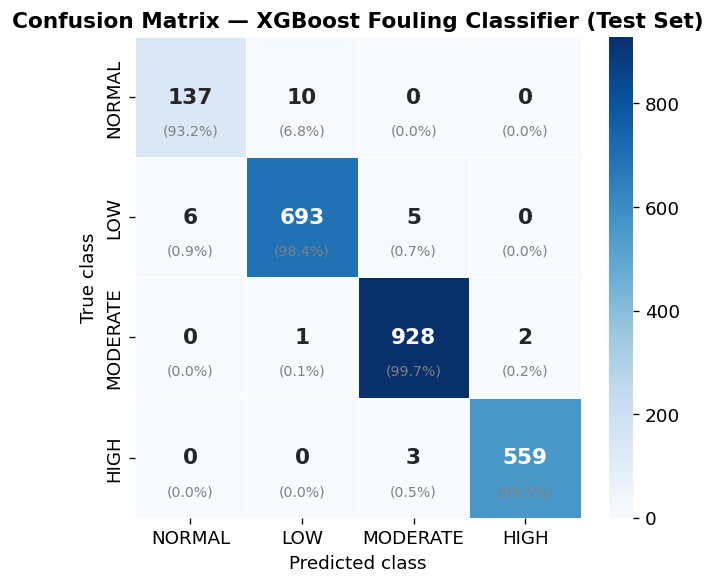

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.2))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax,
            annot_kws={"size": 13, "weight": "bold"}, linewidths=0.5, linecolor="white")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.78, f"({cm_norm[i, j]*100:.1f}%)",
                 ha="center", va="center", fontsize=8.5, color="gray")
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
ax.set_title("Confusion Matrix — XGBoost Fouling Classifier (Test Set)")
plt.show()


### 5.2 ROC and Precision–Recall Curves (One-vs-Rest)

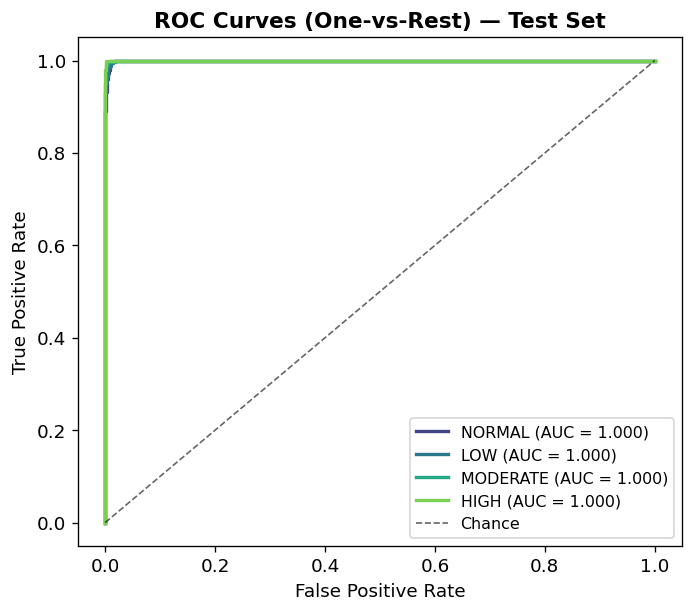

In [ ]:
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASS_ORDER))))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for i, cname in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=PALETTE[i], label=f"{cname} (AUC = {roc_auc_i:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (One-vs-Rest) — Test Set")
ax.legend(loc="lower right", fontsize=9.5)
plt.show()


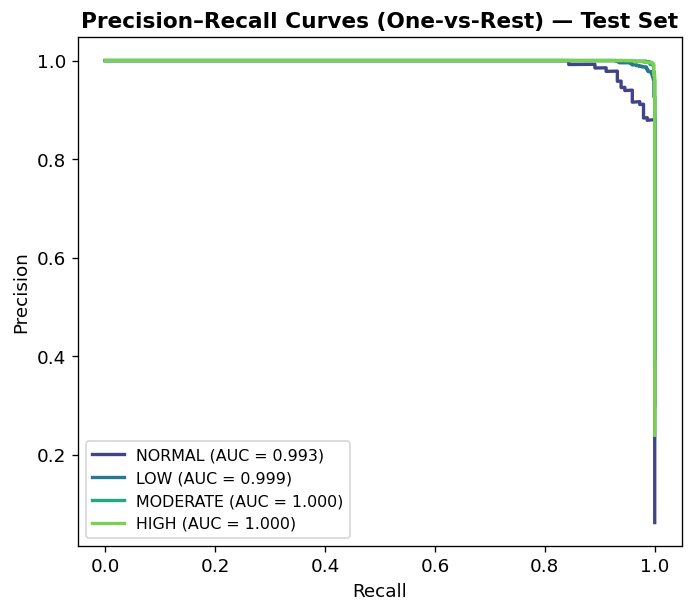

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for i, cname in enumerate(CLASS_ORDER):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, lw=2, color=PALETTE[i], label=f"{cname} (AUC = {pr_auc:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves (One-vs-Rest) — Test Set")
ax.legend(loc="lower left", fontsize=9.5)
plt.show()


### 5.3 Feature Importance and SHAP

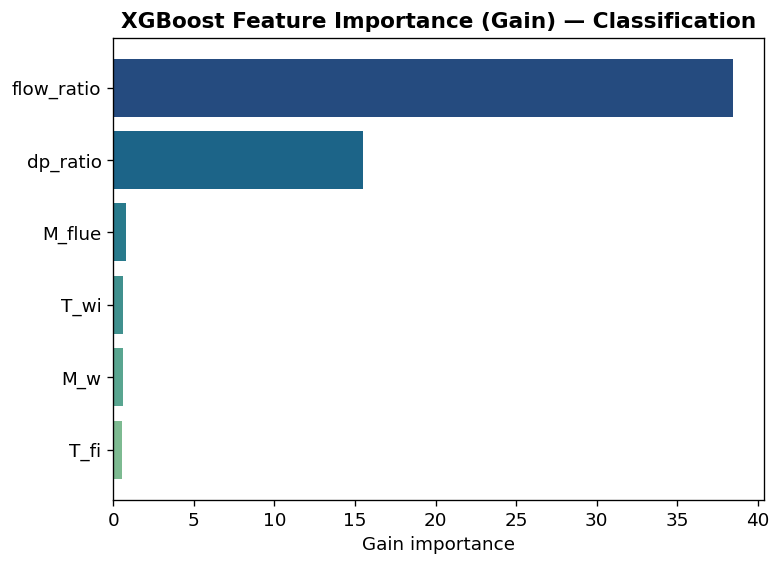

In [ ]:
booster = final_clf.get_booster()
importance = booster.get_score(importance_type="gain")
mapped = {}
for k, v in importance.items():
    idx = int(k.replace("f", "")) if k.startswith("f") and k[1:].isdigit() else None
    name = X.columns[idx] if idx is not None else k
    mapped[name] = v
imp_series = pd.Series(mapped).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_series.index, imp_series.values, color=sns.color_palette("crest", len(imp_series)))
ax.set_xlabel("Gain importance")
ax.set_title("XGBoost Feature Importance (Gain) — Classification")
plt.show()


/tmp/ipykernel_604/959374966.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_abs_mean, X_test_s, plot_size=(7.5, 5.5))


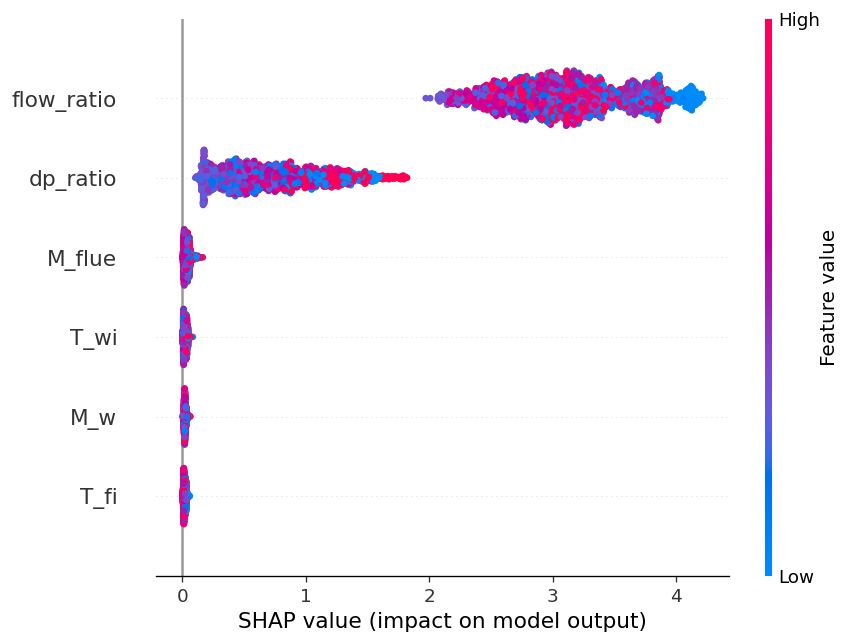

In [ ]:
explainer = shap.TreeExplainer(final_clf)
shap_values = explainer.shap_values(X_test_s)
if isinstance(shap_values, list):
    shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    shap_abs_mean = np.abs(shap_values).mean(axis=2)
else:
    shap_abs_mean = shap_values

shap.summary_plot(shap_abs_mean, X_test_s, plot_size=(7.5, 5.5))


### 5.4 Learning Curve

A small, stable gap between training and cross-validation accuracy across training-set
sizes is the signature of a properly regularized model that is *not* overfitting — contrast
this with the original pipeline, where training accuracy was near-perfect while validation
accuracy lagged far behind.


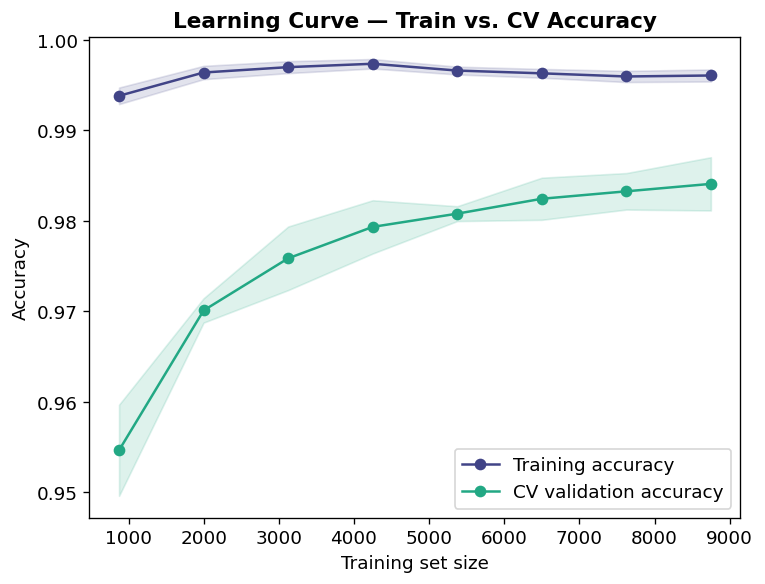

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBClassifier(objective="multi:softprob", num_class=4, eval_metric="mlogloss",
                        random_state=RANDOM_STATE, n_jobs=1, tree_method="hist", **best_params),
    X_train_s, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy", n_jobs=1,
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.plot(train_sizes, train_mean, "o-", color=PALETTE[0], label="Training accuracy")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, "o-", color=PALETTE[2], label="CV validation accuracy")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=PALETTE[2])
ax.set_xlabel("Training set size"); ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Train vs. CV Accuracy")
ax.legend(loc="lower right")
plt.show()


## 6. Regression Pipeline (Continuous Fouling Resistance)

Same leakage-free feature set, predicting the continuous target `R_overall` instead of the
thresholded class. This serves as an independent check: if this regressor *also*
generalizes well, that corroborates the classification result.

We stratify the continuous target by decile bin when splitting, so train/val/test cover
comparable ranges of fouling severity (the regression analogue of `stratify=y_class`).


In [ ]:
y_bins = pd.qcut(y_reg, q=10, labels=False, duplicates="drop")

Xr_train, Xr_temp, yr_train, yr_temp, bins_train, bins_temp = train_test_split(
    X, y_reg, y_bins, test_size=0.30, stratify=y_bins, random_state=RANDOM_STATE
)
Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp, yr_temp, test_size=0.50, stratify=bins_temp, random_state=RANDOM_STATE
)
print(f"train: {len(Xr_train)}  val: {len(Xr_val)}  test: {len(Xr_test)}")

scaler_r = StandardScaler()
Xr_train_s = pd.DataFrame(scaler_r.fit_transform(Xr_train), columns=X.columns, index=Xr_train.index)
Xr_val_s   = pd.DataFrame(scaler_r.transform(Xr_val),   columns=X.columns, index=Xr_val.index)
Xr_test_s  = pd.DataFrame(scaler_r.transform(Xr_test),  columns=X.columns, index=Xr_test.index)


train: 10937  val: 2344  test: 2344


In [ ]:
param_dist_r = {
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "n_estimators": [100, 150, 200],
}

base_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE,
                              n_jobs=1, tree_method="hist")
cv_r = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_r = RandomizedSearchCV(
    estimator=base_reg, param_distributions=param_dist_r, n_iter=20,
    scoring="r2", cv=cv_r, random_state=RANDOM_STATE, n_jobs=1, verbose=1, refit=False,
)
search_r.fit(Xr_train_s, yr_train)

cv_results_r = pd.DataFrame(search_r.cv_results_)
best_idx_r = search_r.best_index_
cv_mean_r = cv_results_r.loc[best_idx_r, "mean_test_score"]
cv_std_r  = cv_results_r.loc[best_idx_r, "std_test_score"]
print("Best params:", search_r.best_params_)
print(f"CV R2: {cv_mean_r:.4f} +/- {cv_std_r:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
CV R2: 0.9967 +/- 0.0001


In [ ]:
best_params_r = search_r.best_params_
final_reg = xgb.XGBRegressor(
    objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1,
    tree_method="hist", early_stopping_rounds=30, **best_params_r,
)
final_reg.fit(
    Xr_train_s, yr_train,
    eval_set=[(Xr_train_s, yr_train), (Xr_val_s, yr_val)],
    verbose=False,
)
print(f"Best iteration (early stopping): {final_reg.best_iteration}")


Best iteration (early stopping): 149


In [ ]:
yr_pred = final_reg.predict(Xr_test_s)
mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print("TEST SET PERFORMANCE (held out, never used in tuning)")
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.4f}")
print(f"\nCross-val R2 (train, 5-fold): {cv_mean_r:.4f} +/- {cv_std_r:.4f}")


TEST SET PERFORMANCE (held out, never used in tuning)
MAE:  0.000020
RMSE: 0.000027
R2:   0.9974

Cross-val R2 (train, 5-fold): 0.9967 +/- 0.0001


### 6.1 Predicted vs. Actual, and Residual Diagnostics

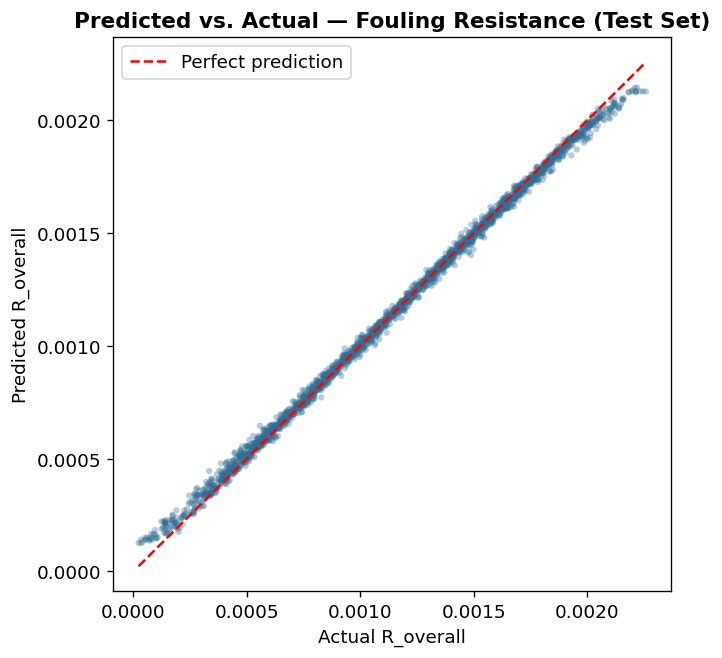

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yr_test, yr_pred, alpha=0.35, s=14, color="#2E6F95", edgecolor="none")
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual R_overall"); ax.set_ylabel("Predicted R_overall")
ax.set_title("Predicted vs. Actual — Fouling Resistance (Test Set)")
ax.legend(loc="upper left")
plt.show()


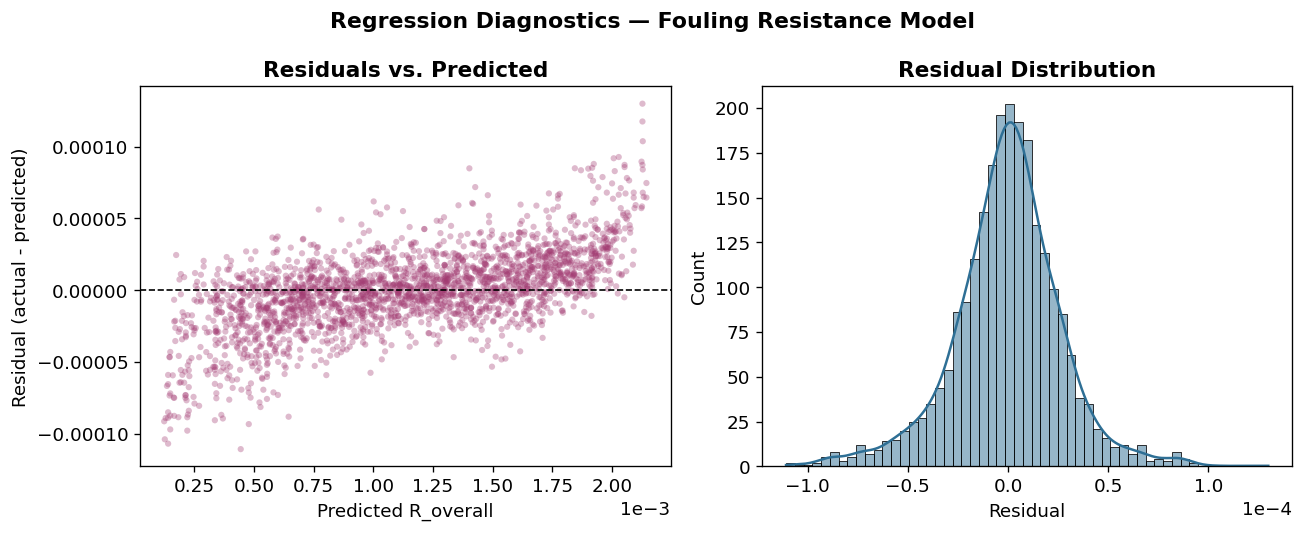

Pearson corr(predicted, residual) = 0.6103 (p=3.13e-239)
A small positive correlation indicates mild heteroscedasticity (residual spread
grows slightly at higher fouling resistance) -- noted in the Discussion, but the
magnitude is small relative to the resistance scale.


In [ ]:
residuals = yr_test - yr_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(yr_pred, residuals, alpha=0.35, s=14, color="#A23B72", edgecolor="none")
axes[0].axhline(0, color="black", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted R_overall"); axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs. Predicted")
axes[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

sns.histplot(residuals, kde=True, ax=axes[1], color="#2E6F95")
axes[1].set_xlabel("Residual"); axes[1].set_title("Residual Distribution")
axes[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
fig.suptitle("Regression Diagnostics — Fouling Resistance Model", fontweight="bold")
plt.tight_layout()
plt.show()

r_corr, p_corr = pearsonr(yr_pred, residuals)
print(f"Pearson corr(predicted, residual) = {r_corr:.4f} (p={p_corr:.2e})")
print("A small positive correlation indicates mild heteroscedasticity (residual spread")
print("grows slightly at higher fouling resistance) -- noted in the Discussion, but the")
print("magnitude is small relative to the resistance scale.")


### 6.2 Feature Importance and SHAP (Regression)

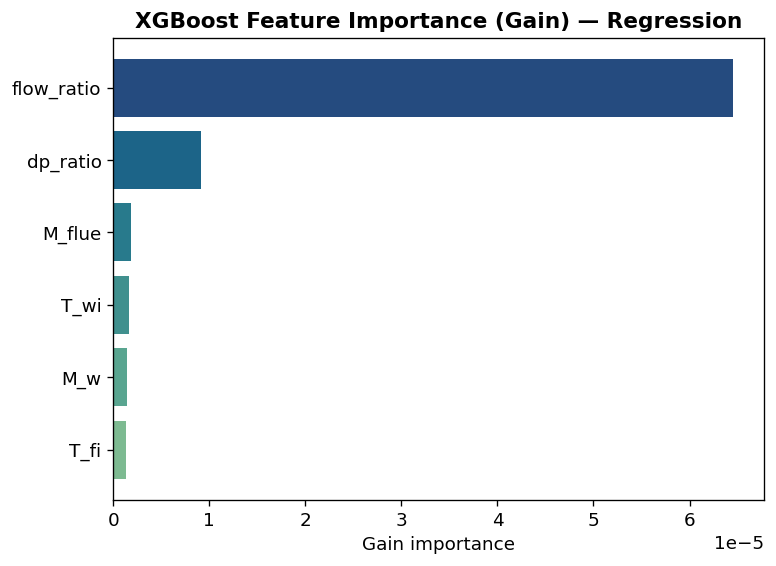

In [ ]:
booster_r = final_reg.get_booster()
importance_r = booster_r.get_score(importance_type="gain")
mapped_r = {}
for k, v in importance_r.items():
    idx = int(k.replace("f", "")) if k.startswith("f") and k[1:].isdigit() else None
    name = X.columns[idx] if idx is not None else k
    mapped_r[name] = v
imp_series_r = pd.Series(mapped_r).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_series_r.index, imp_series_r.values, color=sns.color_palette("crest", len(imp_series_r)))
ax.set_xlabel("Gain importance")
ax.set_title("XGBoost Feature Importance (Gain) — Regression")
plt.show()


/tmp/ipykernel_604/352072147.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_r, Xr_test_s, plot_size=(7.5, 5.5))


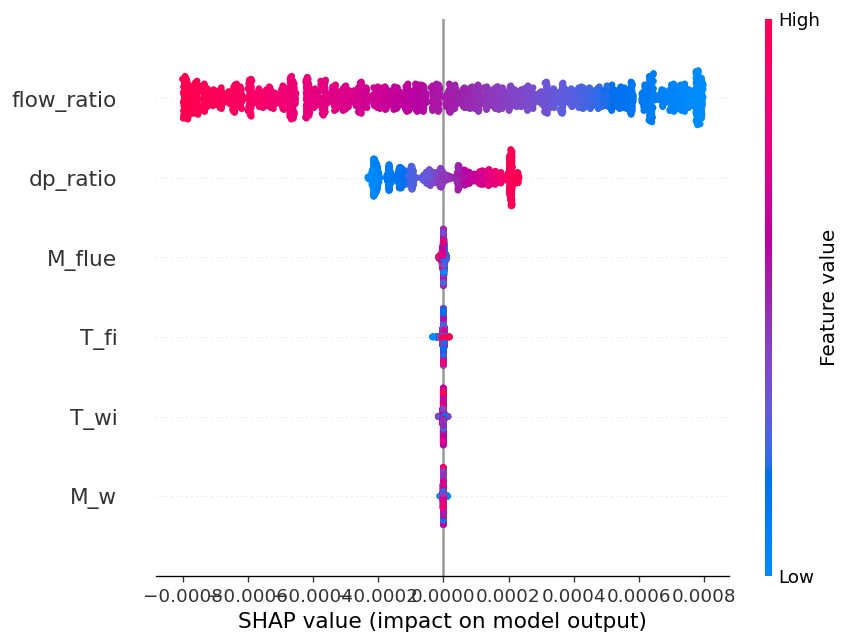

In [ ]:
explainer_r = shap.TreeExplainer(final_reg)
shap_values_r = explainer_r.shap_values(Xr_test_s)
shap.summary_plot(shap_values_r, Xr_test_s, plot_size=(7.5, 5.5))


### 6.3 Learning Curve (Regression)

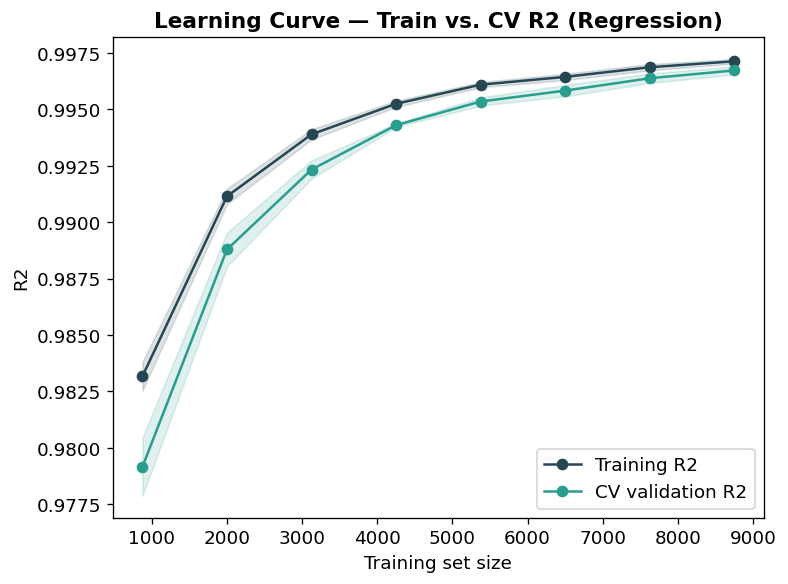

In [ ]:
train_sizes_r, train_scores_r, val_scores_r = learning_curve(
    xgb.XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE,
                       n_jobs=1, tree_method="hist", **best_params_r),
    Xr_train_s, yr_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="r2", n_jobs=1,
)
train_mean_r, train_std_r = train_scores_r.mean(axis=1), train_scores_r.std(axis=1)
val_mean_r, val_std_r = val_scores_r.mean(axis=1), val_scores_r.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.plot(train_sizes_r, train_mean_r, "o-", color="#264653", label="Training R2")
ax.fill_between(train_sizes_r, train_mean_r - train_std_r, train_mean_r + train_std_r, alpha=0.15, color="#264653")
ax.plot(train_sizes_r, val_mean_r, "o-", color="#2A9D8F", label="CV validation R2")
ax.fill_between(train_sizes_r, val_mean_r - val_std_r, val_mean_r + val_std_r, alpha=0.15, color="#2A9D8F")
ax.set_xlabel("Training set size"); ax.set_ylabel("R2")
ax.set_title("Learning Curve — Train vs. CV R2 (Regression)")
ax.legend(loc="lower right")
plt.show()


In [ ]:
summary = pd.DataFrame({
    "Metric": ["CV Accuracy (5-fold)", "Test Accuracy", "Test Precision (macro)",
               "Test Recall (macro)", "Test F1 (macro)", "Test ROC-AUC (macro, OvR)"],
    "Classification": [f"{cv_mean:.4f} ± {cv_std:.4f}", f"{acc:.4f}", f"{prec_macro:.4f}",
                         f"{rec_macro:.4f}", f"{f1_macro:.4f}", f"{roc_auc_macro:.4f}"],
})
print(summary.to_string(index=False))

print()
summary_r = pd.DataFrame({
    "Metric": ["CV R2 (5-fold)", "Test MAE", "Test RMSE", "Test R2"],
    "Regression": [f"{cv_mean_r:.4f} ± {cv_std_r:.4f}", f"{mae:.6f}", f"{rmse:.6f}", f"{r2:.4f}"],
})
print(summary_r.to_string(index=False))


                   Metric  Classification
     CV Accuracy (5-fold) 0.9846 ± 0.0023
            Test Accuracy          0.9885
   Test Precision (macro)          0.9826
      Test Recall (macro)          0.9769
          Test F1 (macro)          0.9797
Test ROC-AUC (macro, OvR)          0.9997

        Metric      Regression
CV R2 (5-fold) 0.9967 ± 0.0001
      Test MAE        0.000020
     Test RMSE        0.000027
       Test R2          0.9974


## 8. Reproducibility Notes

- `RANDOM_STATE = 42` is used consistently for all splits, CV folds, and model
  initialization.
- All preprocessing (`StandardScaler`) is fit **only** on the training split and applied
  (not refit) to validation/test.
- Hyperparameter search uses cross-validation **within the training split only**; the
  validation split is reserved exclusively for early stopping, and the test split is
  touched exactly once, at the end, for final reporting.
- Saved artifacts: `xgb_classifier.json`, `xgb_regressor.json` (native XGBoost format,
  reloadable via `xgb.XGBClassifier().load_model(...)` / `xgb.XGBRegressor().load_model(...)`).


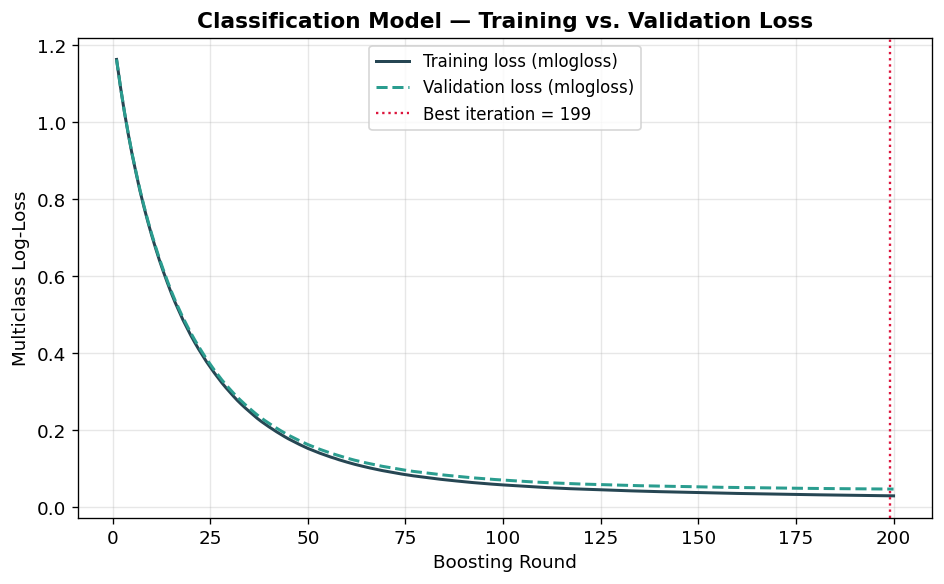

Best iteration : 199
Best train loss: 0.0301
Best val loss  : 0.0477


In [ ]:
# --- Classification: Training vs Validation Log-Loss per boosting round ---
evals_clf = final_clf.evals_result()

train_loss_clf = evals_clf['validation_0']['mlogloss']
val_loss_clf   = evals_clf['validation_1']['mlogloss']
rounds_clf     = range(1, len(train_loss_clf) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rounds_clf, train_loss_clf, label='Training loss (mlogloss)',   color='#264653', lw=1.8)
ax.plot(rounds_clf, val_loss_clf,   label='Validation loss (mlogloss)', color='#2A9D8F', lw=1.8, linestyle='--')
ax.axvline(x=final_clf.best_iteration, color='crimson', lw=1.4,
           linestyle=':', label=f'Best iteration = {final_clf.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multiclass Log-Loss')
ax.set_title('Classification Model — Training vs. Validation Loss')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Best iteration : {final_clf.best_iteration}")
print(f"Best train loss: {train_loss_clf[final_clf.best_iteration]:.4f}")
print(f"Best val loss  : {val_loss_clf[final_clf.best_iteration]:.4f}")

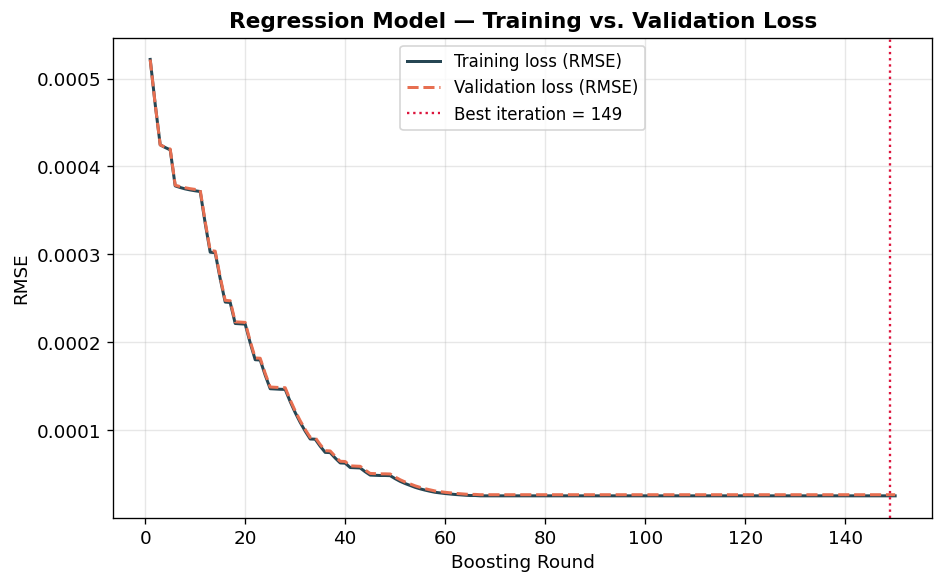

Best iteration : 149
Best train RMSE: 0.000026
Best val RMSE  : 0.000027


In [ ]:
# --- Regression: Training vs Validation RMSE per boosting round ---
evals_reg = final_reg.evals_result()

train_loss_reg = evals_reg['validation_0']['rmse']
val_loss_reg   = evals_reg['validation_1']['rmse']
rounds_reg     = range(1, len(train_loss_reg) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rounds_reg, train_loss_reg, label='Training loss (RMSE)',   color='#264653', lw=1.8)
ax.plot(rounds_reg, val_loss_reg,   label='Validation loss (RMSE)', color='#E76F51', lw=1.8, linestyle='--')
ax.axvline(x=final_reg.best_iteration, color='crimson', lw=1.4,
           linestyle=':', label=f'Best iteration = {final_reg.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('Regression Model — Training vs. Validation Loss')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Best iteration : {final_reg.best_iteration}")
print(f"Best train RMSE: {train_loss_reg[final_reg.best_iteration]:.6f}")
print(f"Best val RMSE  : {val_loss_reg[final_reg.best_iteration]:.6f}")

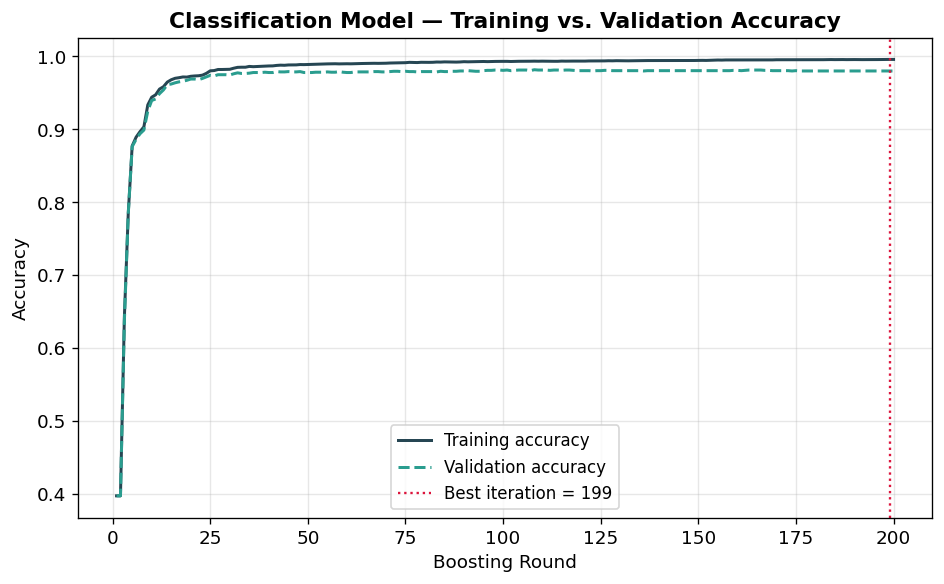

Best iteration     : 199
Train acc at best  : 0.9958
Val acc at best    : 0.9799


In [ ]:
# --- Classification: Training vs Validation Accuracy per boosting round ---
# We compute accuracy at every round using iteration_range

train_acc_per_round = []
val_acc_per_round   = []

total_rounds = final_clf.best_iteration + 1  # only up to best iteration

for i in range(1, total_rounds + 1):
    # Predict using first i trees only
    y_train_pred_i = final_clf.predict(X_train_s, iteration_range=(0, i))
    y_val_pred_i   = final_clf.predict(X_val_s,   iteration_range=(0, i))

    train_acc_per_round.append(accuracy_score(y_train, y_train_pred_i))
    val_acc_per_round.append(accuracy_score(y_val,   y_val_pred_i))

rounds_acc = range(1, total_rounds + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rounds_acc, train_acc_per_round, label='Training accuracy',   color='#264653', lw=1.8)
ax.plot(rounds_acc, val_acc_per_round,   label='Validation accuracy', color='#2A9D8F', lw=1.8, linestyle='--')
ax.axvline(x=final_clf.best_iteration, color='crimson', lw=1.4,
           linestyle=':', label=f'Best iteration = {final_clf.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Accuracy')
ax.set_title('Classification Model — Training vs. Validation Accuracy')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_curve_classification.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best iteration     : {final_clf.best_iteration}")
print(f"Train acc at best  : {train_acc_per_round[final_clf.best_iteration]:.4f}")
print(f"Val acc at best    : {val_acc_per_round[final_clf.best_iteration]:.4f}")

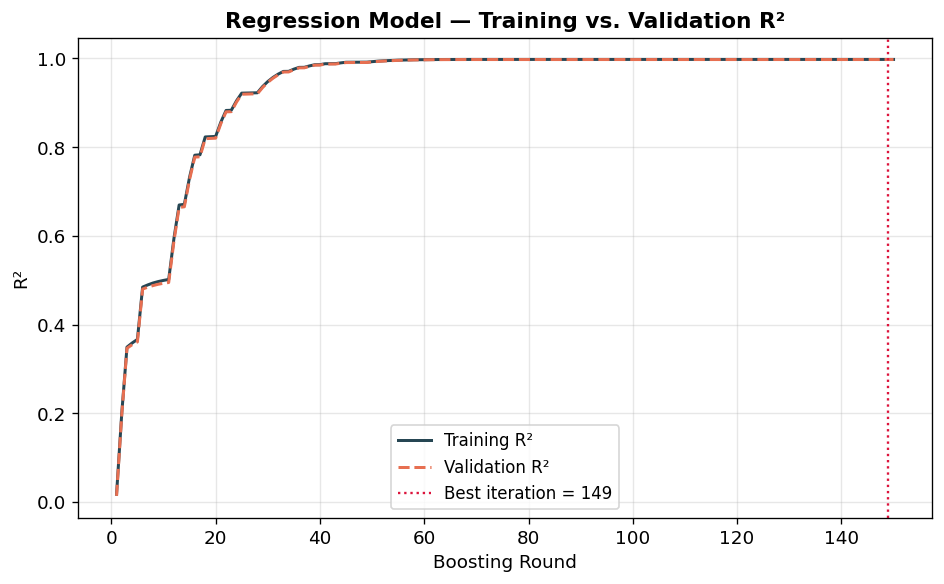

Best iteration   : 149
Train R² at best : 0.9976
Val R² at best   : 0.9974


In [ ]:
# --- Regression: Training vs Validation R² per boosting round ---
# R² is the regression equivalent of accuracy

train_r2_per_round = []
val_r2_per_round   = []

total_rounds_reg = final_reg.best_iteration + 1

for i in range(1, total_rounds_reg + 1):
    yr_train_pred_i = final_reg.predict(Xr_train_s, iteration_range=(0, i))
    yr_val_pred_i   = final_reg.predict(Xr_val_s,   iteration_range=(0, i))

    train_r2_per_round.append(r2_score(yr_train, yr_train_pred_i))
    val_r2_per_round.append(r2_score(yr_val,   yr_val_pred_i))

rounds_r2 = range(1, total_rounds_reg + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rounds_r2, train_r2_per_round, label='Training R²',   color='#264653', lw=1.8)
ax.plot(rounds_r2, val_r2_per_round,   label='Validation R²', color='#E76F51', lw=1.8, linestyle='--')
ax.axvline(x=final_reg.best_iteration, color='crimson', lw=1.4,
           linestyle=':', label=f'Best iteration = {final_reg.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('R²')
ax.set_title('Regression Model — Training vs. Validation R²')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r2_curve_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best iteration   : {final_reg.best_iteration}")
print(f"Train R² at best : {train_r2_per_round[final_reg.best_iteration]:.4f}")
print(f"Val R² at best   : {val_r2_per_round[final_reg.best_iteration]:.4f}")